In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [62]:
#From kaggle the dataset is loaded
df = pd.read_csv(r"C:\Users\saniy\Downloads\german_credit_data.csv")
print(df.head())

   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  Risk  
0           1169         6             radio/TV  good  
1           5951        48             radio/TV   bad  
2           2096        12            education  good  
3           7882        42  furniture/equipment  good  
4           4870        24                  car   bad  


In [32]:
#Handle missing values 
df.fillna("unknown", inplace=True)

In [39]:
#Encoding categorical columns
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])


In [40]:
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


In [41]:
x= df.drop("Risk", axis=1) #dropping the target
y=df["Risk"] #target

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state =42)


In [47]:
rf= RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [52]:
y_pred = rf.predict(x_test)

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision", precision_score)
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.765
Precision <function precision_score at 0x00000286C5709550>
Recall: 0.9148936170212766
F1 Score: 0.8459016393442623
ROC-AUC: 0.6608366390191129


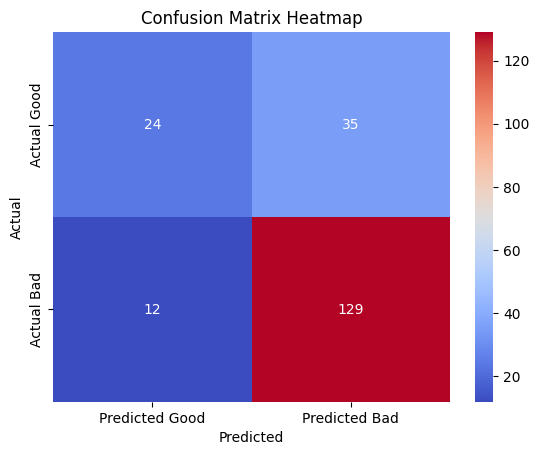

In [60]:
#Confusion matrix compares your model's predictions with the actual data
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm",   # color palette
            xticklabels=["Predicted Good", "Predicted Bad"],
            yticklabels=["Actual Good", "Actual Bad"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()